<a href="https://colab.research.google.com/github/ShymaShameer/Eniac_project/blob/main/Project_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project**
**Case Study: Eniac’s Discount Strategy**


# Importing clean data

In [87]:
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
# orders_qc.csv
url = "https://drive.google.com/file/d/1XdxgRkpP-6QNIy3IxgMZmLcUviATaoad/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
#orders_qc = pd.read_csv(path)
orders_qc=pd.read_csv(path, parse_dates=["created_date"])


# orderlines_qc.csv
url = "https://drive.google.com/file/d/1AQ8m52gsMNqDrzyRTBqjUffjrbbTKrrs/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qc=pd.read_csv(path, parse_dates=["orderlines_date"])

# products_qc.csv
url = "https://drive.google.com/file/d/1awVC0T6x8suaf7Rpzyb5qG-a1WDnVOQc/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_qc=pd.read_csv(path)

#brands
url = 'https://drive.google.com/file/d/1m1ThDDIYRTTii-rqM5SEQjJ8McidJskD/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
brands_df_original = pd.read_csv(path)

In [89]:
# copy of all dataframes
orders_df = orders_qc.copy()
orderlines_df = orderlines_qc.copy()
products_df=products_qc.copy()
brands_df = brands_df_original.copy()

In [90]:
# Display format
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', None) # to increase the width of the columns

# Data Analysis

* What is the time period that the dataset covers? (01-Jan-2017 to 14-Mar-2018)
* What is the overall revenue for that time? (15312354.04 Euro)
* Are there seasonal patterns in the evolution of sales? (yes)
* What are the most sold products?
* What are the products that generate the most revenue?

#### Time period of dataset

In [6]:
orders_df["created_date"].max()

Timestamp('2018-03-14 12:03:52')

In [7]:
orders_df["created_date"].min()

Timestamp('2017-01-01 01:51:47')

#### Overall revenue

In [8]:
orders_df["total_paid"].sum()

np.float64(15312354.04)

#### Seasonal pattern in sales

In [ ]:
#Extract Month as a Name (Jan, Feb...)
orders_df['month_name'] = orders_df["created_date"].dt.strftime('%b')

In [ ]:
avg_month_orders = orders_df.groupby("month_name",as_index=False)["total_paid"].mean().round(2)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
avg_month_orders = avg_month_orders.set_index('month_name').reindex(month_order).reset_index()

In [ ]:
avg_ord_price_time= sns.relplot(kind="line",
            data=avg_month_orders,
            x='month_name',
            y='total_paid',
            height= 4,aspect=1.5);
avg_ord_price_time.set(title="Trend in Average Order Price ", xlabel="Months", ylabel="Average Order Price (Euros)")
avg_ord_price_time.set_xticklabels(rotation=45);

#### Most sold products

In [26]:
most_sold = orderlines_df.groupby("sku").agg(total_sold=('product_quantity', 'sum')).reset_index()

most_sold = most_sold.sort_values('total_sold', ascending=False)
most_sold.head(10)

# details
#most_sold_sku = most_sold['sku'].head(10)
#most_sold_products = orderlines_df.loc[orderlines_df['sku'].isin(most_sold_sku), :]
#most_sold_products

,sku,total_sold
528,APP1190,1015
408,APP0698,826
846,APP1922,551
5720,WDT0183,514
435,APP0927,493
1622,CRU0051,349
4664,SAM0074,347
549,APP1214,282
1138,APP2446,271
3365,NTE0013,264


#### Products with most revenue

In [78]:
orderline_product_revenue= orderlines_df.merge(products_df, on="sku")

In [79]:
orderline_product_revenue['revenue'] = orderline_product_revenue['unit_price'] * orderline_product_revenue['product_quantity']

In [80]:
most_revenue= orderline_product_revenue.groupby("sku")["revenue"].sum().sort_values(ascending= False).reset_index()
most_revenue

,sku,revenue
0,APP2075,212411.11
1,APP2074,156383.56
2,APP2490,145274.00
3,LGE0044,139377.77
4,APP2489,134657.00
...,...,...
5910,KIN0125,3.99
5911,NTE0087-A,2.82
5912,PAR0037,1.99
5913,SEV0021,0.01


In [91]:
orderline_product_revenue.nunique()

,0
id,59808
order_id,45238
product_quantity,27
sku,5915
orderlines_date,59152
unit_price,5764
unit_price_total,7009
name,5869
desc,4435
price,1402


# Discount Analysis

* Discount is difference between orderlines.unit_price and products.price.
* Merging both tables and creating a column "discount".

In [81]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10534 entries, 0 to 10533
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sku        10534 non-null  object 
 1   name       10534 non-null  object 
 2   desc       10534 non-null  object 
 3   price      10534 non-null  float64
 4   in_stock   10534 non-null  int64  
 5   type       10484 non-null  float64
 6   short_sku  10534 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 576.2+ KB


In [82]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59808 entries, 0 to 59807
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                59808 non-null  int64         
 1   order_id          59808 non-null  int64         
 2   product_quantity  59808 non-null  int64         
 3   sku               59808 non-null  object        
 4   orderlines_date   59808 non-null  datetime64[ns]
 5   unit_price        59808 non-null  float64       
 6   unit_price_total  59808 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 3.2+ MB


In [6]:
orderlines_df.describe()

,id,order_id,product_quantity,orderlines_date,unit_price,unit_price_total
count,59808.00,59808.00,59808.00,59808,59808.00,59808.00
mean,1386609.06,414869.50,1.12,2017-09-12 10:23:12.743546112,240.08,253.19
min,1119116.00,241423.00,1.00,2017-01-01 01:46:16,0.01,0.01
25%,1266616.75,363249.75,1.00,2017-06-12 17:06:13,29.90,29.99
50%,1390673.50,417835.50,1.00,2017-10-27 16:58:06,70.39,77.28
75%,1514531.00,470406.00,1.00,2017-12-25 16:56:10.750000128,186.58,208.99
max,1649593.00,527112.00,72.00,2018-03-14 11:58:13,8287.80,13387.77
std,150615.24,65405.01,0.77,NaN,499.38,522.13


In [83]:
orderline_product= orderlines_df.merge(products_df, on="sku")

orderline_product= orderline_product[["order_id","sku","name" ,"product_quantity","unit_price","price","in_stock", "type"]]
orderline_product

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,1,47.49,60.99,1,12755395.00
1,299546,IOT0014,iOttie Easy View 2 Car Black Support,1,18.99,22.95,0,5720.00
2,295347,APP0700,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",1,72.19,89.00,1,13005399.00
3,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",1,2565.99,3209.00,0,1282.00
4,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,1,60.90,76.99,0,1298.00
...,...,...,...,...,...,...,...,...
59803,527035,APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),1,9.99,25.00,1,1230.00
59804,527070,APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),2,9.99,25.00,1,1230.00
59805,527074,APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),2,9.99,25.00,1,1230.00
59806,527096,APP0698,Apple Lightning Cable Connector to USB 1m White (OEM),3,9.99,25.00,1,1230.00


In [84]:
orderline_product["price_discount"] = (orderline_product["price"] - orderline_product["unit_price"])

In [85]:
orderline_product.head()

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,price_discount
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,1,47.49,60.99,1,12755395.00,13.50
1,299546,IOT0014,iOttie Easy View 2 Car Black Support,1,18.99,22.95,0,5720.00,3.96
2,295347,APP0700,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",1,72.19,89.00,1,13005399.00,16.81
3,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",1,2565.99,3209.00,0,1282.00,643.01
4,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,1,60.90,76.99,0,1298.00,16.09


In [8]:
orderline_product["order_id"].nunique()

45238

In [86]:
orderline_product.groupby("sku")["price_discount"].sum()

,price_discount
sku,
8MO0001-A,22.04
8MO0003-A,22.15
8MO0007,89.07
8MO0008,134.10
8MO0009,87.63
...,...
ZAG0040,13.00
ZAG0041,10.00
ZAG0042,10.00


In [9]:
orderline_product.describe().round(2)

,order_id,product_quantity,unit_price,price,in_stock,type,price_discount
count,59808.00,59808.00,59808.00,59808.00,59808.00,59797.00,59808.00
mean,414869.50,1.12,240.08,272.90,0.57,65736271325024.05,32.82
std,65405.01,0.77,499.38,558.56,0.50,610095429849484.50,103.66
min,241423.00,1.00,0.01,2.99,0.00,1216.00,-2078.76
25%,363249.75,1.00,29.90,39.95,0.00,1433.00,5.01
50%,417835.50,1.00,70.39,89.95,1.00,11905404.00,15.01
75%,470406.00,1.00,186.58,217.98,1.00,12755395.00,35.65
max,527112.00,72.00,8287.80,9799.00,1.00,5740000000000000.00,1511.20


* When exploring discounts, need to ensure to always have the **time** dimension in consideration, since Eniac does not always offer its products at the same price. A critical question, is whether revenue grows whenever discounts increase.

# Product categorisation

In [5]:
products_df.groupby("type")[["name", "desc"]].nunique()

,name,desc
type,,
1216.00,67,53
1229.00,107,67
1230.00,73,47
1231.00,10,10
1276.00,19,19
1280.00,5,5
1282.00,354,317
1296.00,187,179
1298.00,833,802


In [6]:
product_category_df = products_df.copy()

In [7]:
product_category_df["category"] = ""

### Type based mapping

In [8]:
from collections import Counter

top_words_per_type = {}

for t in product_category_df["type"].dropna().unique():
    names = product_category_df.loc[product_category_df["type"] == t, "name"].dropna()

    words = []
    for name in names:
        if isinstance(name, str):
            words.extend(name.split())

    word_counts = Counter(words)
    top_words_per_type[t] = [w for w, _ in word_counts.most_common(5)]

top_words_df = pd.DataFrame.from_dict(
    top_words_per_type,
    orient="index",
    columns=["top1","top2","top3","top4","top5"]
).reset_index().rename(columns={"index":"type"})

top_words_df.head(130).tail(15)


,type,top1,top2,top3,top4,top5
111,21632158.00,|,Apple,Mac,Pro,RAM
112,21561716.00,Apple,iPhone,6,Like,new
113,79201715.00,Like,new,-,Apple,iPod
114,51902158.00,|,Apple,Macbook,Air,13
115,5185.00,Apple,Watch,the,1st,Gen.
116,113291716.00,Apple,iPhone,8,64GB,-
117,113281716.00,Apple,iPhone,8,Plus,-
118,113271716.00,Apple,iPhone,X,Space,Gray
119,113464259.00,Apple,TV,4K,32GB,64GB
120,5450000000000000.00,|,Second,hand,-,Apple


In [ ]:
# top_words_df["type"].isin [8696.00,1216.00,1280.00,5720.00,15435404.00,12282.00]== "Suppprt"
# top_words_df["type"].isin [13855401.00,12575403.00,54025401.00,5401.00]== "Keyboard"
# top_words_df["type"].isin [1387.00,]== "Mouse"
# top_words_df["type"].isin [1230.00,1325.00,12995397.00,13955395.00,12355400.00,12755395.00,14365395.00,5395.00,1298.00,13615399.00,12585395.00,11434.00,5399.00]== "Cables & Connectors"
# top_words_df["type"].isin [144000000000.00,146000000000.00]== "Repair"
# top_words_df["type"].isin [5384.00,]== "Headphone"
# top_words_df["type"].isin [1334.00,]== "Router"
# top_words_df["type"].isin [13005399.00,]== "Apple charger"
# top_words_df["type"].isin [13835403.00,]== "MacBook case"
# top_words_df["type"].isin [11865403.00,549000000000.00,5403.00]== "iPhone case"
# top_words_df["type"].isin [	1276.00,11935397.00,12655397.00,1404.00,12175397.00,57445397.00,12215397.00,1364.00],42945397.00,1020000000000.00== "Memory/Storage"
# top_words_df["type"].isin [11905404.00,24821716.00,51601716.00,85641716.00,24811716.00,85651716.00,1716.00,21571716.00,21561716.00,113291716.00,113281716.00,113271716.00]== "iPhone"
# top_words_df["type"].isin [12635403.00	,]== "iPad case"
# top_words_df["type"].isin [1296.00,]== "Monitor"
# top_words_df["type"].isin [12285400.00,]== "iPhone cable drop/ Accessories"
# top_words_df["type"].isin [1229.00,101781405.00]== "Pointer/Pen "
# top_words_df["type"].isin [4259.00,113464259.00]== "Media player"
# top_words_df["type"].isin [14035403.00,13555403.00,1231.00,2425.00]== "Protector"
# top_words_df["type"].isin [12085400.00,]== "Cleaning /lock plate"
# top_words_df["type"].isin [1282.00,5740000000000000.00,544000000000.00,5430000000000000.00,5720000000000000.00,216000000000.00,118692158.00]== "iMac"
# top_words_df["type"].isin [1424.00,]== "External recorder"
# top_words_df["type"].isin [9094.00,5404.00]== "Camera"
# top_words_df["type"].isin [1405.00,12141714.00,42931714.00,13621714.00,24861714.00,51861714.00,1714.00,51871714.00,12051714.00,12031714.00,106431714.00,113851714.00]== "Tablet/ipad"
# top_words_df["type"].isin [14305406.00,1433.00,54085407.00	]== "iMac Kits"
# top_words_df["type"].isin [10142.00,1515.00,12645406.00]== "iMac/iPhone Battery"

# top_words_df["type"].isin [10230.00,1392.00]== "MacBook case/ bag"
# top_words_df["type"].isin [11821715.00,79201715.00]== "iPod"
# top_words_df["type"].isin [5405.00,24215399.00,2434.00,2449.00,24885185.00,24895185.00,5185.00]== "Watch"
# top_words_df["type"].isin [5398.00	,]== "Speaker"
# top_words_df["type"].isin [21485407.00,5407.00,5406.00,]== "iPhone replacement kit"
# top_words_df["type"].isin [20642062.00,]== "Service"
# top_words_df["type"].isin [1375.00,]== "Microphones"
# top_words_df["type"].isin [21535407.00,]== "iPad kit"
# top_words_df["type"].isin [1416.00,]== "Software"
# top_words_df["type"].isin [217000000000.00,2158.00,51882158.00,929000000000.00,21622158.00,539000000000.00,21632158.00,51902158.00,5450000000000000.00,51912158.00		]== "MacBook"
# top_words_df["type"].isin [54864259.00,11859.00]== "Remote/ Sensor"




In [10]:
type_category_map = {
    # Support
    8696: "Support", 1216: "Support", 1280: "Support", 5720: "Support",
    15435404: "Support", 12282: "Support",

    # Keyboard
    13855401: "Keyboard", 12575403: "Keyboard", 54025401: "Keyboard", 5401: "Keyboard",

    # Mouse
    1387: "Mouse",

    # Cables, Adaptors & Connectors
    1230: "Cables & Connectors", 1325: "Cables & Connectors", 12995397: "Cables & Connectors",
    13955395: "Cables & Connectors", 12355400: "Cables & Connectors",
    12755395: "Cables & Connectors", 14365395: "Cables & Connectors",
    5395: "Cables & Connectors", 1298: "Cables & Connectors",
    13615399: "Cables & Connectors", 12585395: "Cables & Connectors",
    11434: "Cables & Connectors", 5399: "Cables & Connectors",13005399:"Cables & Connectors",

    # Repair
    144000000000: "Repair", 146000000000: "Repair",

    # Headphone
    5384: "Headphone",

    # Router
    1334: "Router",



    #iMac Kits
    14305406: "iMac Kits",1433: "iMac Kits",54085407:"iMac Kits",

    #iMac/iPhone Battery
    10142: "iMac/iPhone Battery",1515:"iMac/iPhone Battery", 12645406:"iMac/iPhone Battery",

    # External recorder
    1424.00: "External Recorder",

    # Microphone
    1375.00:"Microphone",

    # iPad Kit
    21535407.00: "iPad Kit",

    # iPhone replacement kit
    21485407.00: "iPhone replacement kit",5407.00: "iPhone replacement kit",5406.00:"iPhone replacement kit",


    # MacBook case
    13835403: "MacBook case/bag",10230.00: "MacBook case/bag",1392.00: "MacBook case/bag",

    # iPhone case
    11865403: "iPhone case", 549000000000: "iPhone case", 5403: "iPhone case",

    # Memory/Storage
    1276: "Memory/Storage", 11935397: "Memory/Storage", 12655397: "Memory/Storage",
    1404: "Memory/Storage", 12175397: "Memory/Storage", 57445397: "Memory/Storage",
    12215397: "Memory/Storage", 1364: "Memory/Storage", 42945397: "Memory/Storage",
    1020000000000: "Memory/Storage",

    # iPhone
    11905404: "iPhone", 24821716: "iPhone", 51601716: "iPhone",
    85641716: "iPhone", 24811716: "iPhone", 85651716: "iPhone",
    1716: "iPhone", 21571716: "iPhone", 21561716: "iPhone",
    113291716: "iPhone", 113281716: "iPhone", 113271716: "iPhone",

    # iPad case
    12635403: "iPad case",

    # Monitor
    1296: "Monitor",

    # Accessories
    12285400: "iPhone Accessories",

    # Pointer / Pen
    1229: "Pointer/Pen", 101781405: "Pointer/Pen",

    # Media player
    4259: "Media player", 113464259: "Media player",

    # Protector
    14035403: "Protector", 13555403: "Protector", 1231: "Protector", 2425: "Protector",

    # Cleaning
    12085400: "Cleaning",

    # iMac
    1282: "iMac", 5740000000000000: "iMac", 544000000000: "iMac",
    5430000000000000: "iMac", 5720000000000000: "iMac",
    216000000000: "iMac", 118692158: "iMac",

    # Camera
    9094: "Camera", 5404: "Camera",

    #iPod
    11821715.00: "iPod",79201715.00: "iPod",

    # Tablet/iPad
    1405: "Tablet/iPad", 12141714: "Tablet/iPad", 42931714: "Tablet/iPad",
    13621714: "Tablet/iPad", 24861714: "Tablet/iPad", 51861714: "Tablet/iPad",
    1714: "Tablet/iPad", 51871714: "Tablet/iPad", 12051714: "Tablet/iPad",
    12031714: "Tablet/iPad", 106431714: "Tablet/iPad", 113851714: "Tablet/iPad",

    # Watch
    5405: "Watch", 24215399: "Watch", 2434: "Watch",
    2449: "Watch", 24885185: "Watch", 24895185: "Watch", 5185: "Watch",

    # Speaker
    5398: "Speaker",

    # Service
    20642062: "Service",

    # Software
    1416: "Software",

    # MacBook
    217000000000: "MacBook", 2158: "MacBook", 51882158: "MacBook",
    929000000000: "MacBook", 21622158: "MacBook",
    539000000000: "MacBook", 21632158: "MacBook",
    51902158: "MacBook", 5450000000000000: "MacBook", 51912158: "MacBook",

    # Remote / Sensor
    54864259: "Remote/Sensor", 11859: "Remote/Sensor"
}

In [11]:
product_category_df["category"] = product_category_df["type"].map(type_category_map).fillna(product_category_df["category"])

In [12]:
rules = {
    "iPhone": "iPhone",
    "ipad": "Tablet/iPad",
    "Mac": "MacBook",
    "Drive|Memory|Synology": "Storage",
    "Headphones": "Headphone",
    "Thunderbolt":"Cables & Connectors",
    "Chime":"Speaker"

}

mask = product_category_df["type"].isna() | (product_category_df["type"] == 0)

for keyword, category in rules.items():
    product_category_df.loc[
        mask & product_category_df["name"].str.contains(keyword, case=False, na=False),
        "category"
    ] = category

In [13]:
product_category_df.loc[
    product_category_df["category"]== ""	,
    :
].sort_values("category")

,sku,name,desc,price,in_stock,type,short_sku,category


In [14]:
product_category_df["category"].value_counts()

,count
category,
Memory/Storage,2556
Cables & Connectors,1625
iPhone case,1128
iMac,760
iPhone,737
iPad case,368
MacBook case/bag,363
Watch,354
iMac Kits,266


## Creating  Categories & subcategories

In [15]:
product_category_df["sub_category"] = product_category_df["category"]

In [16]:
category_map = {
    # 1. Mobile Devices
    "iPhone": "Mobile Devices",
    "iPhone replacement kit": "Mobile Devices",
    "iPad Kit": "Mobile Devices",
    "Tablet/iPad": "Mobile Devices",
    "iPod": "Mobile Devices",

    # 2. Computers
    "MacBook": "Computers",
    "iMac": "Computers",

    # 3. Computer Accessories
    "Keyboard": "Computer Accessories",
    "Mouse": "Computer Accessories",
    "Monitor": "Computer Accessories",
    "Pointer/Pen": "Computer Accessories",

    # 4. Mobile Accessories
    "iPhone case": "Mobile Accessories",
    "iPad case": "Mobile Accessories",
    "MacBook case/bag": "Mobile Accessories",
    "iPhone Accessories": "Mobile Accessories",
    "Protector": "Mobile Accessories",

    # 5. Connectivity & Power
    "Cables & Connectors": "Connectivity & Power",
    "Router": "Connectivity & Power",

    # 6. Audio & Media
    "Headphone": "Audio & Media",
    "Speaker": "Audio & Media",
    "Microphone": "Audio & Media",
    "Media player": "Audio & Media",

    # 7. Storage
    "Memory/Storage": "Storage",
     "Storage": "Storage",

    # 8. Repair & Services
    "Repair": "Repair & Services",
    "Service": "Repair & Services",
    "iMac Kits": "Repair & Services",
    "iMac/iPhone Battery": "Repair & Services",

    # 9. Smart Devices & Cameras
    "Camera": "Smart Devices & Cameras",
    "Watch": "Smart Devices & Cameras",
    "Remote/Sensor": "Smart Devices & Cameras",

    # 10. Software & Others
    "Software": "Software & Others",
    "Cleaning": "Software & Others",
    "Support": "Software & Others",
    "External Recorder": "Software & Others"
}

In [17]:
product_category_df["category"] = product_category_df["sub_category"].map(category_map)

In [18]:
#product_category_df["category"].value_counts()
product_category_df["sub_category"].value_counts()

,count
sub_category,
Memory/Storage,2556
Cables & Connectors,1625
iPhone case,1128
iMac,760
iPhone,737
iPad case,368
MacBook case/bag,363
Watch,354
iMac Kits,266


In [19]:
product_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10534 entries, 0 to 10533
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           10534 non-null  object 
 1   name          10534 non-null  object 
 2   desc          10534 non-null  object 
 3   price         10534 non-null  float64
 4   in_stock      10534 non-null  int64  
 5   type          10484 non-null  float64
 6   short_sku     10534 non-null  object 
 7   category      10534 non-null  object 
 8   sub_category  10534 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 740.8+ KB


# Price Analysis

## Category Price Analysis with discount

In [36]:
product_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10534 entries, 0 to 10533
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sku        10534 non-null  object 
 1   name       10534 non-null  object 
 2   desc       10534 non-null  object 
 3   price      10534 non-null  float64
 4   in_stock   10534 non-null  int64  
 5   type       10484 non-null  float64
 6   short_sku  10534 non-null  object 
 7   category   10534 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 658.5+ KB


In [37]:
product_categories_df = product_category_df[["sku","name","desc","price","in_stock","type","category"]]

In [38]:
product_categories_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10534 entries, 0 to 10533
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       10534 non-null  object 
 1   name      10534 non-null  object 
 2   desc      10534 non-null  object 
 3   price     10534 non-null  float64
 4   in_stock  10534 non-null  int64  
 5   type      10484 non-null  float64
 6   category  10534 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 576.2+ KB


In [39]:
orderline_product_cat= orderlines_df.merge(product_categories_df, on="sku")

orderline_product_cat= orderline_product_cat[["order_id","sku","name" ,"product_quantity","unit_price","price","in_stock", "type","category"]]
orderline_product_cat.head()

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,category
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,1,47.49,60.99,1,12755395.00,Cables & Connectors
1,299546,IOT0014,iOttie Easy View 2 Car Black Support,1,18.99,22.95,0,5720.00,Support
2,295347,APP0700,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",1,72.19,89.00,1,13005399.00,Apple charger
3,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",1,2565.99,3209.00,0,1282.00,iMac
4,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,1,60.90,76.99,0,1298.00,Cables & Connectors


In [43]:
orderline_product_cat["price_discount"] = (orderline_product_cat["price"] - orderline_product_cat["unit_price"])
orderline_product_cat["price_discount%"] = ((orderline_product_cat["price_discount"]/ orderline_product_cat["price"])*100)


In [44]:
orderline_product_cat.head()

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,category,price_discount,price_discount%
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,1,47.49,60.99,1,12755395,Connectivity,13.50,22.13
1,299546,IOT0014,iOttie Easy View 2 Car Black Support,1,18.99,22.95,0,5720,Connectivity,3.96,17.25
2,295347,APP0700,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",1,72.19,89.00,1,13005399,Connectivity,16.81,18.89
3,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",1,2565.99,3209.00,0,1282,Storage,643.01,20.04
4,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,1,60.90,76.99,0,1298,Storage,16.09,20.90


* Discounted products

In [46]:
# average discount  for each category
orderline_product_cat.groupby("category")["price_discount%"].mean().sort_values(ascending= False)

,price_discount%
category,
Protection,31.77
Phone Accessories,29.55
Camera,28.37
Smart audio,25.69
Connectivity,22.73
Maintenance & Cleaning,22.24
Computer Accessories,20.16
Watch,19.83
Remote,18.82


Connectivity, Smart audio, and Phone Accessories have the highest cumulative discounts, indicating heavy discounting in these categories, while Smartphone and Services show negative values, suggesting pricing inconsistencies or potential data issues.

* Distribution of price across categories- min, max

In [45]:
orderline_product_cat.groupby("category")["price"].mean().sort_values(ascending= False)

,price
category,
Storage,510.68
Smartphone,498.86
Laptop/ Tablet,240.95
Computer Accessories,217.90
Camera,214.15
Watch,188.67
Other,181.42
Smart audio,111.39
Misc Hardware,99.95


## Category Price Analysis with Revenue

In [49]:
# 1. Actual Revenue (what you actually earned)
orderline_product_cat['actual_revenue'] = orderline_product_cat['unit_price'] * orderline_product_cat['product_quantity']

# 2. Gross Revenue (full price value)
orderline_product_cat['gross_revenue'] = orderline_product_cat['price'] * orderline_product_cat['product_quantity']

# 3. Lost Revenue (value lost to discounts)
orderline_product_cat['discount_loss'] = orderline_product_cat['gross_revenue'] - orderline_product_cat['actual_revenue']

In [52]:
cat_price_revenue= orderline_product_cat[["category","unit_price","price",
                                          "product_quantity","price_discount", "price_discount%",
                                          "actual_revenue","gross_revenue","discount_loss"]]

In [55]:
cat_price_revenue.tail()

,category,unit_price,price,product_quantity,price_discount,price_discount%,actual_revenue,gross_revenue,discount_loss
59803,Smart audio,9.99,25.00,1,15.01,60.04,9.99,25.00,15.01
59804,Smart audio,9.99,25.00,2,15.01,60.04,19.98,50.00,30.02
59805,Smart audio,9.99,25.00,2,15.01,60.04,19.98,50.00,30.02
59806,Smart audio,9.99,25.00,3,15.01,60.04,29.97,75.00,45.03
59807,Smart audio,9.99,25.00,1,15.01,60.04,9.99,25.00,15.01


In [53]:
cat_price_revenue.groupby("category")["discount_loss"].sum().sort_values(ascending= False)

,discount_loss
category,
Storage,1257242.31
Smart audio,225334.51
Computer Accessories,168312.39
Laptop/ Tablet,161652.95
Connectivity,156084.01
Phone Accessories,83812.82
Watch,30165.40
Camera,14679.92
Smartphone,6410.29


Storage contributes the highest discount loss by a large margin, indicating it is the most heavily discounted category, while most other categories have significantly lower impact and Services even show a slight negative loss.

# Category based analysis

In [20]:
orderline_product_cat= orderlines_df.merge(product_category_df, on="sku")

orderline_product_cat= orderline_product_cat[["order_id","sku","name" ,"product_quantity","unit_price","price","in_stock", "type","category","sub_category"]]
orderline_product_cat.head()

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,category,sub_category
0,299545,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD iMac 2011,1,47.49,60.99,1,12755395.00,Connectivity & Power,Cables & Connectors
1,299546,IOT0014,iOttie Easy View 2 Car Black Support,1,18.99,22.95,0,5720.00,Software & Others,Support
2,295347,APP0700,"Apple 85W MagSafe 2 charger MacBook Pro screen Retina 15 ""(OEM)",1,72.19,89.00,1,13005399.00,Connectivity & Power,Cables & Connectors
3,299549,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB | 2TB Drive Fusion",1,2565.99,3209.00,0,1282.00,Computers,iMac
4,299556,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,1,60.90,76.99,0,1298.00,Connectivity & Power,Cables & Connectors


In [21]:
orderline_product_cat.groupby("category",as_index=False)["order_id"].count()

,category,order_id
0,Audio & Media,3332
1,Computer Accessories,4646
2,Computers,2210
3,Connectivity & Power,10008
4,Mobile Accessories,9541
5,Mobile Devices,8629
6,Repair & Services,3772
7,Smart Devices & Cameras,1562
8,Software & Others,978
9,Storage,15130


In [23]:
orderline_product_cat.nunique()

,0
order_id,45238
sku,5915
name,5869
product_quantity,27
unit_price,5764
price,1402
in_stock,2
type,122
category,10
sub_category,34


In [22]:
orderline_product_cat['revenue'] = orderline_product_cat['unit_price'] * orderline_product_cat['product_quantity']

In [66]:
# Summarising all data for product category
category_stats = (
    orderline_product_cat.groupby("category", as_index=False)
    .agg(
        order_count=('order_id', 'count'),
        avg_price=('price', 'mean'),
        min_price=('price', 'min'),
        max_price=('price', 'max'),
        total_revenue=("revenue","sum")
    )
    .round(2) # Clean up decimals
)

# Sort by order_count to see the most popular categories first
category_stats = category_stats.sort_values('order_count', ascending=False)

category_stats

,category,order_count,avg_price,min_price,max_price,total_revenue
9,Storage,15130,305.77,4.99,9799.00,4492215.00
3,Connectivity & Power,10008,77.88,4.79,3799.00,664571.45
4,Mobile Accessories,9541,52.33,7.90,349.00,381698.43
5,Mobile Devices,8629,373.72,2.99,3199.90,3148982.31
1,Computer Accessories,4646,219.08,4.90,1576.99,979095.43
6,Repair & Services,3772,104.17,2.99,807.97,337014.70
0,Audio & Media,3332,152.98,3.49,799.00,439489.87
2,Computers,2210,2215.28,23.60,8249.00,4368437.34
7,Smart Devices & Cameras,1562,205.19,15.00,1269.00,282105.58
8,Software & Others,978,56.41,7.99,689.00,49233.57


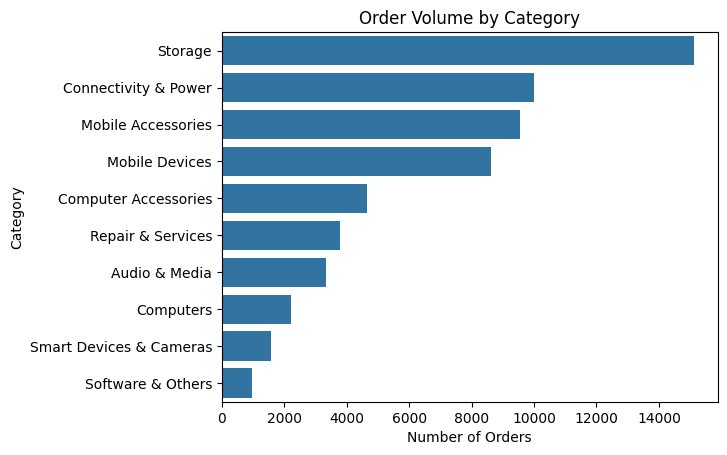

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=category_stats.sort_values("order_count", ascending=False),
    x="order_count",
    y="category"
)

plt.title("Order Volume by Category")
plt.xlabel("Number of Orders")
plt.ylabel("Category")
plt.show()

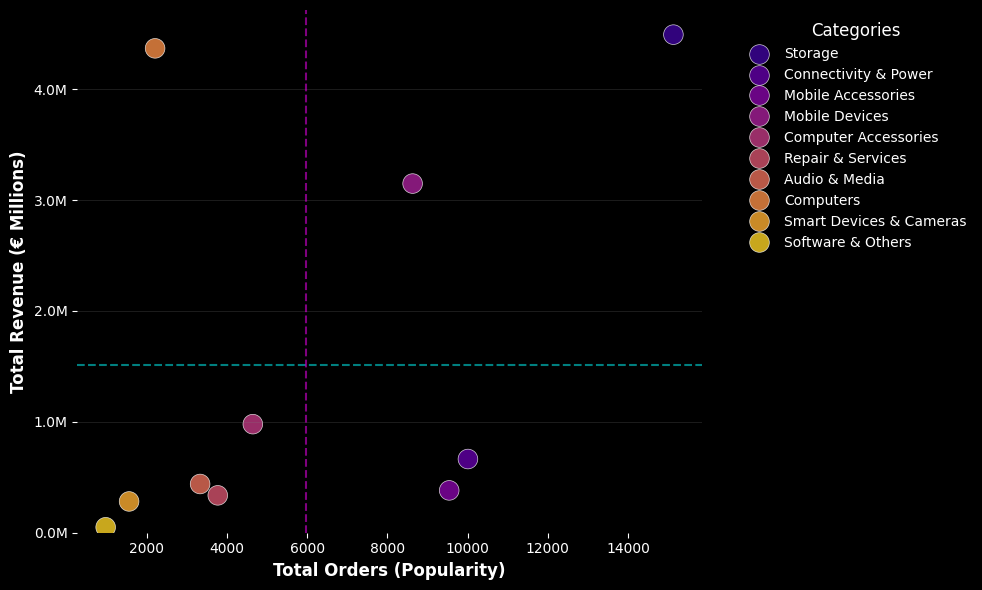

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter # Added for formatting

# 1. Set the dark theme globally
plt.style.use('dark_background')
plt.figure(figsize=(10, 6)) # Slightly wider for the legend

# 2. Define a formatter function for Millions
def format_millions(x, pos):
    return f'{x/1e6:.1f}M' # Divides the number by 1,000,000 and adds 'M'

# 3. Create the scatter plot
sns.scatterplot(
    data=category_stats,
    x='order_count',
    y='total_revenue',
    s=200,
    hue="category",
    palette='plasma',
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

# 4. Clean up borders and set Y-limit
sns.despine(left=True, bottom=True)
plt.ylim(0) # Forces the chart to start at €0 instead of €0.2M

# 5. Formatting Labels & Million Format
plt.xlabel('Total Orders (Popularity)', fontsize=12, fontweight='bold', color='white')
plt.ylabel('Total Revenue (€ Millions)', fontsize=12, fontweight='bold', color='white')
plt.xticks(color='white')

# Apply the Million formatter to the Y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.yticks(color='white')

# Adjust grid
plt.grid(axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# 6. Handle the Legend
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False,
    title="Categories",
    title_fontsize='12',
    fontsize='10',
    labelcolor='white'
)

# 7. Baselines
plt.axhline(category_stats['total_revenue'].mean(), color='cyan', linestyle='--', alpha=0.5, label='Avg Revenue')
plt.axvline(category_stats['order_count'].mean(), color='magenta', linestyle='--', alpha=0.5, label='Avg Volume')

plt.tight_layout()
plt.show()

##### Exploring Storage category

In [28]:
storage_cat= orderline_product_cat.loc[orderline_product_cat["category"]=="Storage",:]
storage_cat

,order_id,sku,name,product_quantity,unit_price,price,in_stock,type,category,sub_category,revenue
8,299571,SYN0139,Synology DS216j NAS Server Mac and PC,1,166.24,175.99,0,12175397.00,Storage,Memory/Storage,166.24
14,299600,LAC0205,LaCie d2 Hard Drive 3TB Thunderbolt 2 USB 3.0,1,246.99,259.00,0,11935397.00,Storage,Memory/Storage,246.99
25,299634,SYN0146,Synology NAS Server DS416Play Mac and PC,1,369.54,434.99,0,12175397.00,Storage,Memory/Storage,369.54
26,299637,TOS0007,"Toshiba 1TB 25 ""SATA 5400rpm hard drive Mac and PC",1,53.19,62.99,1,12655397.00,Storage,Memory/Storage,53.19
27,299571,WDT0183,"Red 4TB WD 35 ""Mac PC hard drive and NAS",1,151.99,169.00,1,12655397.00,Storage,Memory/Storage,151.99
...,...,...,...,...,...,...,...,...,...,...,...
59748,526641,OWC0039-2,Mac memory OWC 8GB (2x4GB) SO-DIMM DDR3 1600MHZ,1,87.99,93.98,1,1364.00,Storage,Memory/Storage,87.99
59756,526777,OWC0035-2,Mac memory OWC 8GB (2x4GB) SO-DIMM DDR3 1066MHZ,1,86.99,87.98,1,1364.00,Storage,Memory/Storage,86.99
59757,526778,SEA0049,"Seagate Barracuda 1TB Hard Drive 35 ""SATA for Mac and PC",1,41.20,59.00,1,12655397.00,Storage,Memory/Storage,41.20
59760,526843,LAC0206-A,Open - LaCie Porsche Design Desktop Lightgrey 4TB USB 3.0,1,108.23,139.99,0,11935397.00,Storage,Memory/Storage,108.23


In [37]:
storage_cat["price_discount"] = (storage_cat["price"] - storage_cat["unit_price"])
storage_cat["price_discount%"] = ((storage_cat["price_discount"]/ storage_cat["price"])*100)

/tmp/ipykernel_5867/3682835137.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  storage_cat["price_discount"] = (storage_cat["price"] - storage_cat["unit_price"])
/tmp/ipykernel_5867/3682835137.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  storage_cat["price_discount%"] = ((storage_cat["price_discount"]/ storage_cat["price"])*100)


In [38]:
storage_cat.describe().round(2)

,order_id,product_quantity,unit_price,price,in_stock,type,revenue,price_discount,price_discount%
count,15130.00,15130.00,15130.00,15130.00,15130.00,15130.00,15130.00,15130.00,15130.00
mean,408546.80,1.20,274.37,305.77,0.57,45720327097.92,296.91,31.39,2.96
std,65187.64,1.09,508.32,548.92,0.49,211032267597.47,524.14,78.97,98.82
min,241423.00,1.00,3.99,4.99,0.00,1276.00,3.99,-2078.76,-1159.20
25%,355048.25,1.00,76.99,89.99,0.00,11935397.00,80.99,8.00,6.83
50%,407980.50,1.00,124.99,139.99,1.00,11935397.00,135.99,20.20,13.86
75%,461847.25,1.00,229.90,255.00,1.00,12655397.00,265.98,40.00,21.43
max,526863.00,72.00,8287.80,9799.00,1.00,1020000000000.00,8287.80,1511.20,90.97


In [29]:
storage_cat.groupby("sku")["price"].sum().sort_values(ascending= False)

,price
sku,
APP2075,228085.71
APP2074,171140.99
APP2264,94017.00
APP2266,92093.00
APP2080,82512.73
...,...
KIN0126,11.98
LEX0019,10.99
LEX0012,7.99


* Creating price category for **Storage**

In [39]:
# Define the bins and the labels
bins = [0, 50, 250, 1000, 3000, 10000]
labels = [
    "Low Cost",
    "Budget",
    "Mid Range",
    "High Value",
    "Premium"
]

# Create the new column
storage_cat['price_tier'] = pd.cut(storage_cat['price'], bins=bins, labels=labels)


/tmp/ipykernel_5867/1309987010.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  storage_cat['price_tier'] = pd.cut(storage_cat['price'], bins=bins, labels=labels)


In [40]:
# Check the distribution
storage_cat['price_tier'].value_counts()

,count
price_tier,
Budget,9558
Mid Range,3023
Low Cost,1695
High Value,688
Premium,166


In [44]:
# Summarising all data for Storage category
storage_stats = (
    storage_cat.groupby("price_tier", as_index=False)
    .agg(
        order_count=('order_id', 'count'),
        avg_price=('price', 'mean'),
        min_price=('price', 'min'),
        max_price=('price', 'max'),
        total_revenue=("revenue","sum"),
        total_discount=("price_discount","sum")
    )
    .round(2) # Clean up decimals
)

# Sort by order_count to see the most popular categories first
storage_stats = storage_stats.sort_values('order_count', ascending=False)

storage_stats

/tmp/ipykernel_5867/1870559956.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  storage_cat.groupby("price_tier", as_index=False)


,price_tier,order_count,avg_price,min_price,max_price,total_revenue,total_discount
1,Budget,9558,131.82,50.28,249.99,1296377.11,155552.04
2,Mid Range,3023,446.00,250.99,989.00,1282025.91,177115.55
0,Low Cost,1695,31.47,4.99,49.99,83232.58,-13135.92
3,High Value,688,2013.49,1008.99,2989.00,1293984.04,109643.91
4,Premium,166,3490.46,3035.92,9799.00,536595.36,45820.53


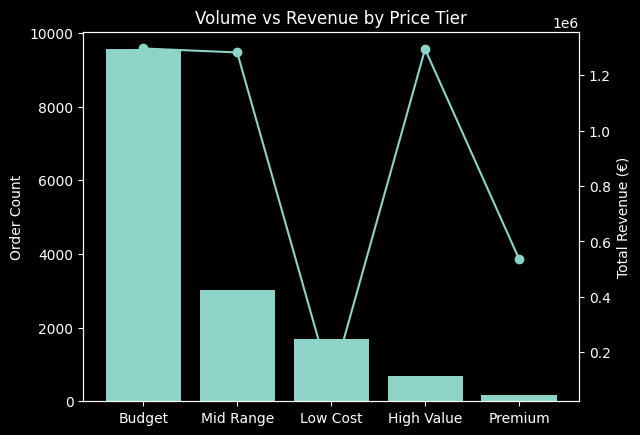

In [46]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Bar: Order Count
ax1.bar(storage_stats["price_tier"], storage_stats["order_count"])
ax1.set_ylabel("Order Count")

# Line: Revenue
ax2 = ax1.twinx()
ax2.plot(storage_stats["price_tier"], storage_stats["total_revenue"], marker='o')
ax2.set_ylabel("Total Revenue (€)")

plt.title("Volume vs Revenue by Price Tier")
plt.show()

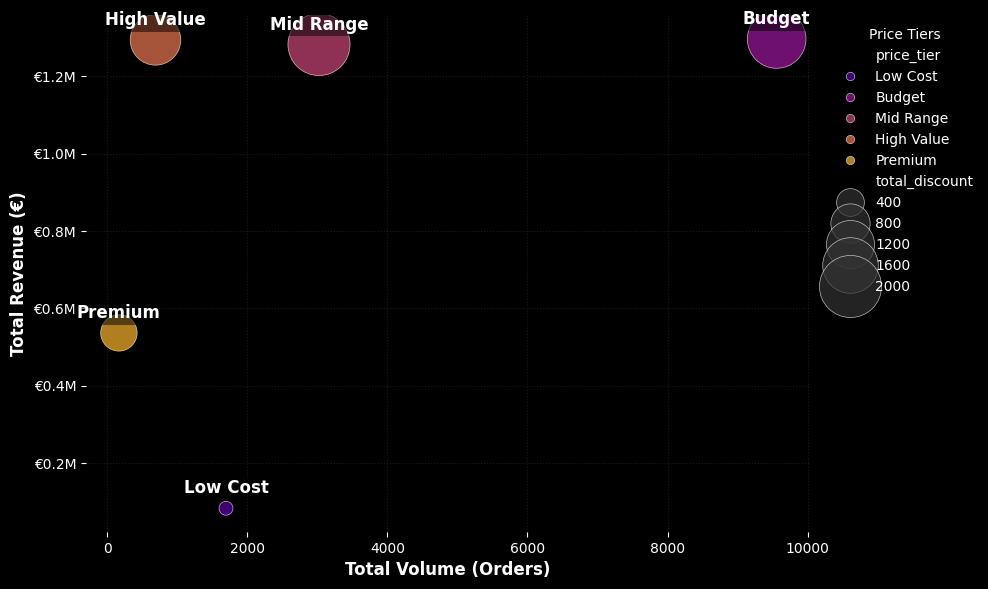

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# Helper function to turn 1,000,000 into "1.0M"
def millions(x, pos):
    return f'€{x*1e-6:1.1f}M'



# 1. Theme and Figure Setup
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6)) # Slightly wider for the legend

# 2. Advanced Bubble Scaling
# We use a Min-Max scaler to keep bubbles between 100 and 2000 units
min_s, max_s = 100, 2000
raw_size = storage_stats["total_discount"]
bubble_size = ((raw_size - raw_size.min()) / (raw_size.max() - raw_size.min()) * (max_s - min_s) + min_s)

# 3. Create the Scatter Plot
# Using 'hue' with 'price_tier' ensures all 5 categories get distinct plasma colors
scatter = sns.scatterplot(
    data=storage_stats,
    x='order_count',
    y='total_revenue',
    size=bubble_size,
    hue='price_tier',
    palette='plasma',
    sizes=(min_s, max_s),
    alpha=0.7,
    edgecolor='white',
    linewidth=0.5,
    legend='brief' # Ensures we see the price tiers in the legend
)

# 4. Smart Labeling (Avoiding the 'Mess')
# We label each tier once at its average position or highest point
for tier in storage_stats['price_tier'].unique():
    subset = storage_stats[storage_stats['price_tier'] == tier]
    # Find the 'leading' product in each tier (highest revenue)
    top_point = subset.loc[subset['total_revenue'].idxmax()]

    plt.text(
        top_point['order_count'],
        top_point['total_revenue'] + (storage_stats['total_revenue'].max() * 0.03),
        tier,
        fontsize=12,
        fontweight='bold',
        color='white',
        ha='center',
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2) # Text shadow
    )

# 5. Clean up Borders and Grid
sns.despine(left=True, bottom=True)
plt.grid(axis='both', color='gray', linestyle=':', alpha=0.2)

# 6. Labels and Legend
plt.xlabel("Total Volume (Orders)", fontsize=12, fontweight='bold', color='white')
plt.ylabel("Total Revenue (€)", fontsize=12, fontweight='bold', color='white')


# Apply it to the Y-axis
ax.yaxis.set_major_formatter(FuncFormatter(millions))

#plt.title("Revenue vs. Volume by Price Tier\nSize represents Total Discount Volume", fontsize=18, pad=25)

# Fix the legend so it doesn't cover the bubbles
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, title="Price Tiers")

plt.tight_layout()
plt.show()